# **CSC 380 HW\#3 (Spring 2026) Kuzushiji-46**

Starter code

### **TO-DO (0)**: Max Barajas 2281541

In [57]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf

print(tf.__version__)

2.20.0


In [94]:
# Japanese font setup for matplotlib
!apt-get install -y fonts-ipafont-gothic -qq

from matplotlib import font_manager

font_manager.fontManager.addfont(
    "/usr/share/fonts/truetype/fonts-japanese-gothic.ttf"
)

matplotlib.rcParams["font.family"] = "IPAGothic"

print("Japanese font ready:", matplotlib.rcParams["font.family"])

Japanese font ready: ['IPAGothic']


## 1. Load data

In [95]:
DEPO_URL = (
    "https://raw.githubusercontent.com/"
    "ntomuro/CSC380/main/HW3-Kuzushiji-46/"
)

# Download data files
!wget -O train.npz {DEPO_URL}train.npz
!wget -O val.npz {DEPO_URL}val.npz
!wget -O test.npz {DEPO_URL}test.npz
!wget -O class_map.csv {DEPO_URL}class_map.csv

# Training data
train = np.load("train.npz")
X_train, y_train = train["images"], train["labels"]
print(f"Training: x={X_train.shape}, y={y_train.shape}")

# Global variables
input_shape = X_train.shape[1:-1]
num_classes = len(np.unique(y_train))
print(f"  input image shape={input_shape}")
print(f"  num of classes={num_classes}")

# Validation data
val = np.load("val.npz")
X_val, y_val = val["images"], val["labels"]
print(f"Validation: x={X_val.shape}, y={y_val.shape}")

# Test data
test = np.load("test.npz")
X_test = test["images"]
print(f"Test: x={X_test.shape}")

--2026-05-23 02:21:18--  https://raw.githubusercontent.com/ntomuro/CSC380/main/HW3-Kuzushiji-46/train.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14099381 (13M) [application/octet-stream]
Saving to: ‘train.npz’

train.npz           100%[===================>]  13.45M  --.-KB/s    in 0.08s   

2026-05-23 02:21:18 (179 MB/s) - ‘train.npz’ saved [14099381/14099381]

--2026-05-23 02:21:18--  https://raw.githubusercontent.com/ntomuro/CSC380/main/HW3-Kuzushiji-46/val.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3019707 (2.



```
```

## 2. Preprocess data

### **TO-DO (1)**: Normalize images so that each pixel value will be a floating number and between 0.0 and 1.0 (by dividing by 255.0).

In [96]:
# TO-DO (1)
train_images = X_train / 255.0
val_images = X_val / 255.0
test_images = X_test / 255.0

train_labels = y_train
val_labels = y_val

## 3. Build/Define the model

We will use a multi-layer feed-forward network (also called MFFNN). The starter model is quite simple: input layer + one hidden layer + output layer.

In [97]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=input_shape),
    tf.keras.layers.Dense(512, activation="relu"),    # 256 → 512
    tf.keras.layers.Dense(num_classes),
])

print(f"Total parameters: {model.count_params():,}")

Total parameters: 425,518


## 4. Compile the model

Before the model is ready for training, it needs a few more settings. These are added during the model's compile step:
<ul>
<li><b>Optimizer</b> —This is how the model is updated based on the data it sees and its loss function.  Notable hyperparameters are <b>learning_rate</b> and <b>weight_decay</b>.
<li><b>Loss function</b> —This measures how accurate the model is during training. You want to minimize this function to "steer" the model in the right direction.
<li><b>Metrics</b> —Used to monitor the training and testing steps. The following example uses accuracy, the fraction of the images that are correctly classified.
</ul>

In [98]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

# DON'T CHANGE the loss function
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"],
)

## 5. Train the model

We train the model, using the training and validation data, with optimizer.  We can specify/override the number of epochs in the parameter too.

In [99]:
history = model.fit(
    train_images,
    train_labels,
    validation_data=(val_images, val_labels),
    epochs=6,
)

Epoch 1/6
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6919 - loss: 1.2003 - val_accuracy: 0.7864 - val_loss: 0.8073
Epoch 2/6
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8315 - loss: 0.6243 - val_accuracy: 0.8297 - val_loss: 0.6363
Epoch 3/6
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8789 - loss: 0.4339 - val_accuracy: 0.8419 - val_loss: 0.5989
Epoch 4/6
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9120 - loss: 0.3172 - val_accuracy: 0.8451 - val_loss: 0.5797
Epoch 5/6
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9338 - loss: 0.2319 - val_accuracy: 0.8551 - val_loss: 0.5776
Epoch 6/6
1510/1510 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9509 - loss: 0.1703 - val_accuracy: 0.8444 - val_loss: 0.6271


### **TO-DO (2)**: Plot the performance that compares training vs. validation sets, on accuracy and loss.

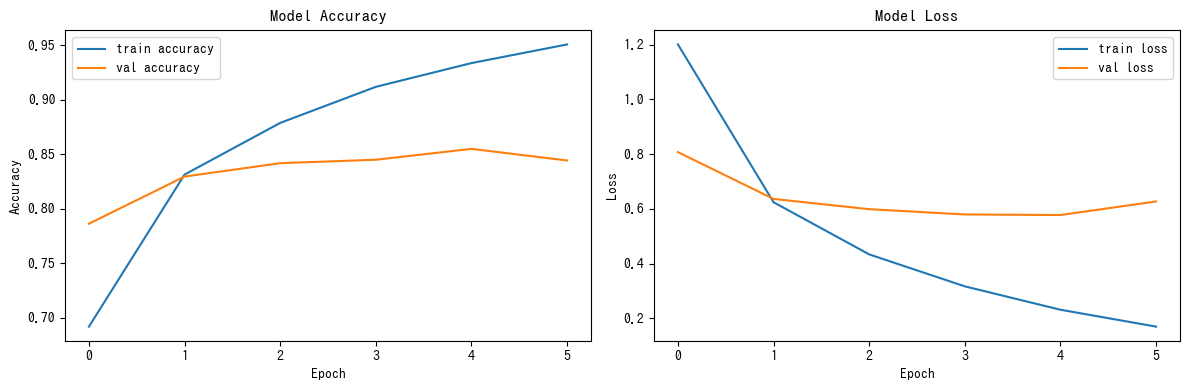

In [101]:
# TO-DO (2):
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='train accuracy')
axes[0].plot(history.history['val_accuracy'], label='val accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'], label='train loss')
axes[1].plot(history.history['val_loss'], label='val loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Make predictions

With the model trained, you can use it to make predictions on some images. Attach a **softmax layer** to convert the model's linear outputs—logits to **probabilities** (for each class), which should be easier to interpret.

In [102]:
probability_model = tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax(),
])

### **TO-DO (3)** Generate predictions for the **test** images

In [103]:
# TO-DO (3):
predictions = probability_model.predict(test_images)
print(predictions.shape)

324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10350, 46)


## **TO-DO (4)**: Write the test predictions in a file (for Kaggle submission).

In [90]:
# TO-DO (4):
import pandas as pd

# Create a DataFrame with the predictions
column_names = [f"Class_{i}" for i in range(num_classes)]
submission = pd.DataFrame(predictions, columns=column_names)

# Add the ID column at the front
submission.insert(0, "ID", range(len(predictions)))

# Save to CSV (no index column, just the data)
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv")
print(submission.head())

Saved submission.csv
   ID       Class_0       Class_1       Class_2       Class_3       Class_4  \
0   0  1.274738e-08  1.036592e-05  2.346668e-08  8.426593e-09  2.386941e-05   
1   1  9.534480e-08  2.942623e-08  1.398461e-12  1.527949e-12  7.635623e-05   
2   2  5.453914e-10  1.586330e-13  4.402853e-10  1.602320e-15  4.246175e-07   
3   3  1.547616e-05  9.157876e-07  4.308966e-06  1.765373e-06  1.908346e-03   
4   4  9.023748e-01  3.229372e-04  2.201773e-05  2.645131e-04  8.698660e-03   

        Class_5       Class_6       Class_7       Class_8  ...      Class_36  \
0  1.409868e-12  1.216355e-06  7.139686e-09  1.889481e-09  ...  6.981206e-08   
1  3.296254e-08  1.841346e-10  2.795323e-08  2.303048e-08  ...  3.115571e-09   
2  2.664101e-10  6.040533e-06  4.785370e-11  3.375545e-11  ...  9.963010e-12   
3  3.057255e-04  1.509422e-06  9.162013e-04  1.155813e-04  ...  2.951000e-07   
4  1.037889e-06  4.371523e-04  2.489028e-04  2.956860e-04  ...  2.599974e-05   

       Class_37      Cl